# Análise Exploratória dos Dados

Este notebook apresenta uma **Análise Exploratória de Dados (Exploratory Data Analysis — EDA)** sobre o conjunto de dados utilizado para modelar o valor mediano dos imóveis (`MEDV`).

O objetivo desta etapa é compreender a **estrutura, qualidade e distribuição dos dados**, além de investigar as relações entre as variáveis antes da construção de modelos estatísticos ou de aprendizado de máquina. A análise também busca identificar possíveis problemas, como valores faltantes, duplicatas, assimetria, observações discrepantes, relações não lineares e multicolinearidade.

A análise será dividida em quatro partes:

## 1. Qualidade e estrutura dos dados

Inicialmente, será realizada uma inspeção geral do conjunto de dados, verificando:

- dimensões do dataset;
- tipos das variáveis;
- valores faltantes;
- observações duplicadas;
- estatísticas descritivas.

Também será analisada a **natureza de cada variável**. Algumas variáveis possuem características particulares que devem ser consideradas posteriormente na modelagem, como:

- `CHAS`, uma variável binária;
- `RAD`, um índice discreto com poucos valores distintos;
- `ZN`, que apresenta uma grande quantidade de valores iguais a zero.

Além disso, será investigado o comportamento da variável resposta `MEDV`. Essa variável apresenta **censura no valor 50**, com aproximadamente 16 observações exatamente iguais a `50.0`. Essa concentração no limite superior pode influenciar a análise dos resíduos e, portanto, deve ser considerada durante a modelagem.

## 2. Análise univariada

Em seguida, será analisada individualmente a distribuição de cada variável.

Serão utilizados:

- histogramas e estimativas de densidade;
- medidas de assimetria;
- medidas de curtose.

A variável `MEDV` receberá atenção especial. Caso seja observada uma assimetria à direita significativa, será avaliada a transformação


log(MEDV)


como alternativa para obter uma distribuição mais adequada e potencialmente melhorar propriedades dos resíduos, como normalidade e homocedasticidade.

Algumas variáveis preditoras, como `CRIM`, `LSTAT`, `DIS` e `NOX`, também podem apresentar assimetria acentuada. Para essas variáveis, serão avaliadas possíveis transformações, como **logaritmo**, buscando obter distribuições mais adequadas para a modelagem.

## 3. Relação de cada preditor com `MEDV`

Após compreender individualmente cada variável, será investigada a relação entre os preditores e a variável resposta `MEDV`.

Serão utilizados gráficos de dispersão de `MEDV` em função de cada variável preditora, acompanhados de uma curva suavizada **LOWESS**, permitindo verificar se as relações observadas são aproximadamente lineares ou apresentam algum padrão de não linearidade.

Também serão analisados:

- boxplots de `MEDV` para os diferentes valores de `CHAS`;
- boxplots de `MEDV` para possíveis faixas de `RAD`;
- padrões de agrupamento ou concentração de observações.

Espera-se, por exemplo, observar uma relação aproximadamente linear e positiva entre `RM` e `MEDV`, enquanto `LSTAT` pode apresentar um comportamento mais curvo. Esses padrões podem indicar a necessidade de transformações ou da inclusão de termos não lineares, como termos quadráticos.

Também será dada atenção especial às variáveis `TAX` e `RAD`, nas quais podem existir agrupamentos de observações com valores idênticos, capazes de influenciar a interpretação das relações e dos modelos ajustados.

## 4. Multicolinearidade

Por fim, será investigada a dependência entre as variáveis preditoras, com o objetivo de identificar possíveis problemas de **multicolinearidade**.

Serão utilizados:

- matriz de correlação de **Pearson**;
- heatmaps das correlações;
- **Variance Inflation Factor (VIF)**;
- número de condição da matriz de design.

O VIF será calculado para cada variável, dando atenção especial a valores elevados, particularmente aqueles acima de **5 a 10**, que podem indicar problemas relevantes de multicolinearidade.

Os resultados dessa etapa servirão para orientar decisões posteriores sobre a seleção e transformação das variáveis, incluindo a possibilidade de **remover ou combinar variáveis** ou utilizar métodos de regularização, como **Ridge** e **Lasso**.

---

> **Objetivo final da EDA:** compreender as características dos dados e identificar padrões ou problemas que devem ser considerados antes da construção e avaliação dos modelos de regressão.

In [86]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [87]:
output_fig_dir = '../results/figures'
os.makedirs(output_fig_dir, exist_ok=True)

In [88]:
df = pd.read_csv("../data/housing.csv")

In [89]:
def gerar_subplot_hist(variaveis: list[str], size: tuple[int, int], name: str):

    n_cols = 4
    n_rows = math.ceil(len(variaveis)/n_cols)

    fig, axes = plt.subplots(
        ncols=n_cols,
        nrows=n_rows,
        figsize=size
    )

    axes = axes.ravel()

    for ax, variavel in zip(axes, variaveis):
        sns.histplot(
            data=df,
            x=variavel,
            ax=ax,
            kde=True
        )

        assimetria = df[variavel].skew()
        curtose = df[variavel].kurt()

        ax.set_title(
            f"{variavel}\n"
            f"Assimetria: {assimetria:.2f} | Curtose: {curtose:.2f}"
        )

        ax.set_ylabel("Frequência")

    # Remove os subplots vazios
    for ax in axes[len(variaveis):]:
        ax.remove()

    plt.tight_layout()

    plt.savefig(
        f'{output_fig_dir}/{name}.png',
        dpi=300
    )
    
    plt.show()

def gerar_subplot_regplot(variaveis: list[str], y: str, size: tuple[int, int], name: str):

    n_cols = 4
    n_rows = math.ceil(len(variaveis)/n_cols)
    
    fig, axes = plt.subplots(
        ncols=n_cols,
        nrows=n_rows,
        figsize=size
    )
    
    axes = axes.ravel()
    
    for ax, variavel in zip(axes.ravel(), variaveis):
        sns.regplot(
            data=df,
            x=variavel,
            y=y,
            ax=ax,
            lowess=True,
            line_kws={'color': 'red'}
        )

        ax.set_title(f'{y} x {variavel}')
    
    # Remove os subplots vazios
    for ax in axes[len(variaveis):]:
        ax.remove()
    
    plt.tight_layout()

    plt.savefig(
        f'{output_fig_dir}/{name}.png',
        dpi=300
    )
    
    plt.show()

def calcular_vif(df: pd.DataFrame, colunas_numericas: list[str]):
    X = df[colunas_numericas].dropna().copy()
    X_com_const = add_constant(X)
    
    # 3. Calcula o VIF para cada variável
    vif_data = pd.DataFrame()
    vif_data["Variável"] = X_com_const.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_com_const.values, i)  # type: ignore
        for i in range(X_com_const.shape[1])
    ]
    
    # 4. Remove a linha do intercepto do resultado final
    vif_data = vif_data[vif_data["Variável"] != "const"].reset_index(drop=True)
    
    # Ordena do maior VIF para o menor
    return vif_data.sort_values(by="VIF", ascending=False)


## **Parte 1: Qualidade e estrutura dos dados**

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     511 non-null    float64
 1   ZN       511 non-null    float64
 2   INDUS    511 non-null    float64
 3   CHAS     511 non-null    int64  
 4   NOX      511 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      511 non-null    float64
 7   DIS      511 non-null    float64
 8   RAD      511 non-null    int64  
 9   TAX      511 non-null    int64  
 10  PTRATIO  511 non-null    float64
 11  B        511 non-null    float64
 12  LSTAT    511 non-null    float64
 13  MEDV     511 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 56.0 KB


In [91]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,511.000000,511.000000,511.000000,511.000000,511.000000,506.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,3.584139,11.252446,11.151096,0.068493,0.554757,6.287589,68.616243,3.783876,9.485323,407.440313,18.500000,356.600900,12.879550,22.682192
std,8.564433,23.234838,6.828175,0.252838,0.115310,0.703802,28.099130,2.098631,8.688469,167.903532,2.200348,90.882679,7.797416,9.484262
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082325,0.000000,5.190000,0.000000,0.449000,5.885500,45.050000,2.100350,4.000000,279.500000,17.400000,374.710000,7.065000,17.050000
50%,0.261690,0.000000,9.690000,0.000000,0.538000,6.209000,77.300000,3.152300,5.000000,330.000000,19.100000,391.340000,11.450000,21.200000
75%,3.621175,12.500000,18.100000,0.000000,0.624000,6.629750,94.050000,5.118000,24.000000,666.000000,20.200000,396.210000,17.105000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,23.000000,396.900000,76.000000,67.000000


In [92]:
for i in df.columns:
    print(f"Valores únicos de {i}: {df[i].nunique()}")

Valores únicos de CRIM: 509
Valores únicos de ZN: 26
Valores únicos de INDUS: 79
Valores únicos de CHAS: 2
Valores únicos de NOX: 82
Valores únicos de RM: 444
Valores únicos de AGE: 357
Valores únicos de DIS: 416
Valores únicos de RAD: 9
Valores únicos de TAX: 67
Valores únicos de PTRATIO: 47
Valores únicos de B: 360
Valores únicos de LSTAT: 460
Valores únicos de MEDV: 231


In [93]:
print((df["MEDV"] == 50.0).sum())
df["MEDV"].value_counts().sort_index(ascending=False).head(10)

16


MEDV
67.0     1
54.0     1
50.0    16
48.8     1
48.5     1
48.3     1
46.7     1
46.0     1
45.4     1
44.8     1
Name: count, dtype: int64

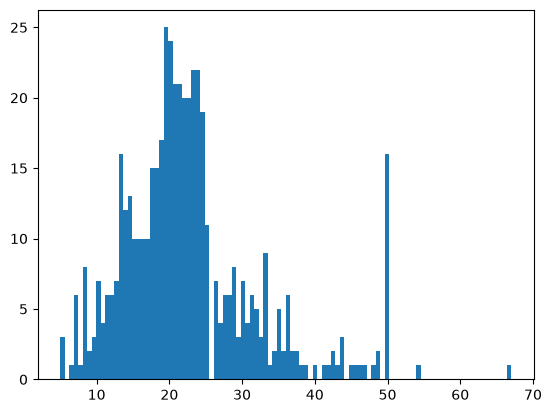

In [94]:
plt.hist(df["MEDV"], bins=100)
plt.show()  

### Conclusão - Qualidade e estrutura dos dados

A análise inicial mostrou que o conjunto de dados possui **511 observações e 14 variáveis**, sendo 11 variáveis do tipo `float64` e 3 do tipo `int64`. De modo geral, os dados apresentam uma estrutura adequada para a análise, sem problemas generalizados de valores ausentes.

Entretanto, foi identificado um problema específico na variável `RM`, que possui **5 valores ausentes**, enquanto as demais variáveis apresentam 511 observações não nulas. Essa ausência deverá ser tratada antes da etapa de modelagem, avaliando-se posteriormente uma estratégia adequada, como imputação ou remoção das observações.

A análise do número de valores únicos também permitiu identificar diferentes naturezas entre as variáveis. `CHAS` possui apenas **2 valores distintos**, caracterizando uma variável binária. `RAD` apresenta apenas **9 valores distintos**, reforçando seu caráter de variável discreta. `ZN`, por sua vez, possui apenas **26 valores distintos**, indicando uma concentração significativa de observações em determinados valores.

As demais variáveis apresentam maior quantidade de valores distintos, sendo tratadas predominantemente como variáveis contínuas. Destacam-se `CRIM`, com 509 valores únicos, `LSTAT`, com 460, e `RM`, com 444 valores únicos entre as 506 observações disponíveis.

Por fim, a variável resposta `MEDV` apresentou uma característica particularmente importante: existem **16 observações exatamente iguais a 50,0**, enquanto os valores próximos apresentam uma quantidade consideravelmente menor de observações. Essa concentração no limite superior indica a presença de **censura no valor 50**, característica que pode afetar a distribuição da variável resposta e, consequentemente, os resíduos e os pressupostos dos modelos de regressão.

Portanto, embora o conjunto de dados apresente uma estrutura geral adequada, a análise revelou três pontos que deverão receber atenção nas próximas etapas: **os valores ausentes em `RM`, a natureza discreta ou concentrada de algumas variáveis e a censura de `MEDV` em 50**. Esses aspectos serão considerados durante a análise univariada e na investigação das relações entre as variáveis.

## **Parte 2: Análise univariada**

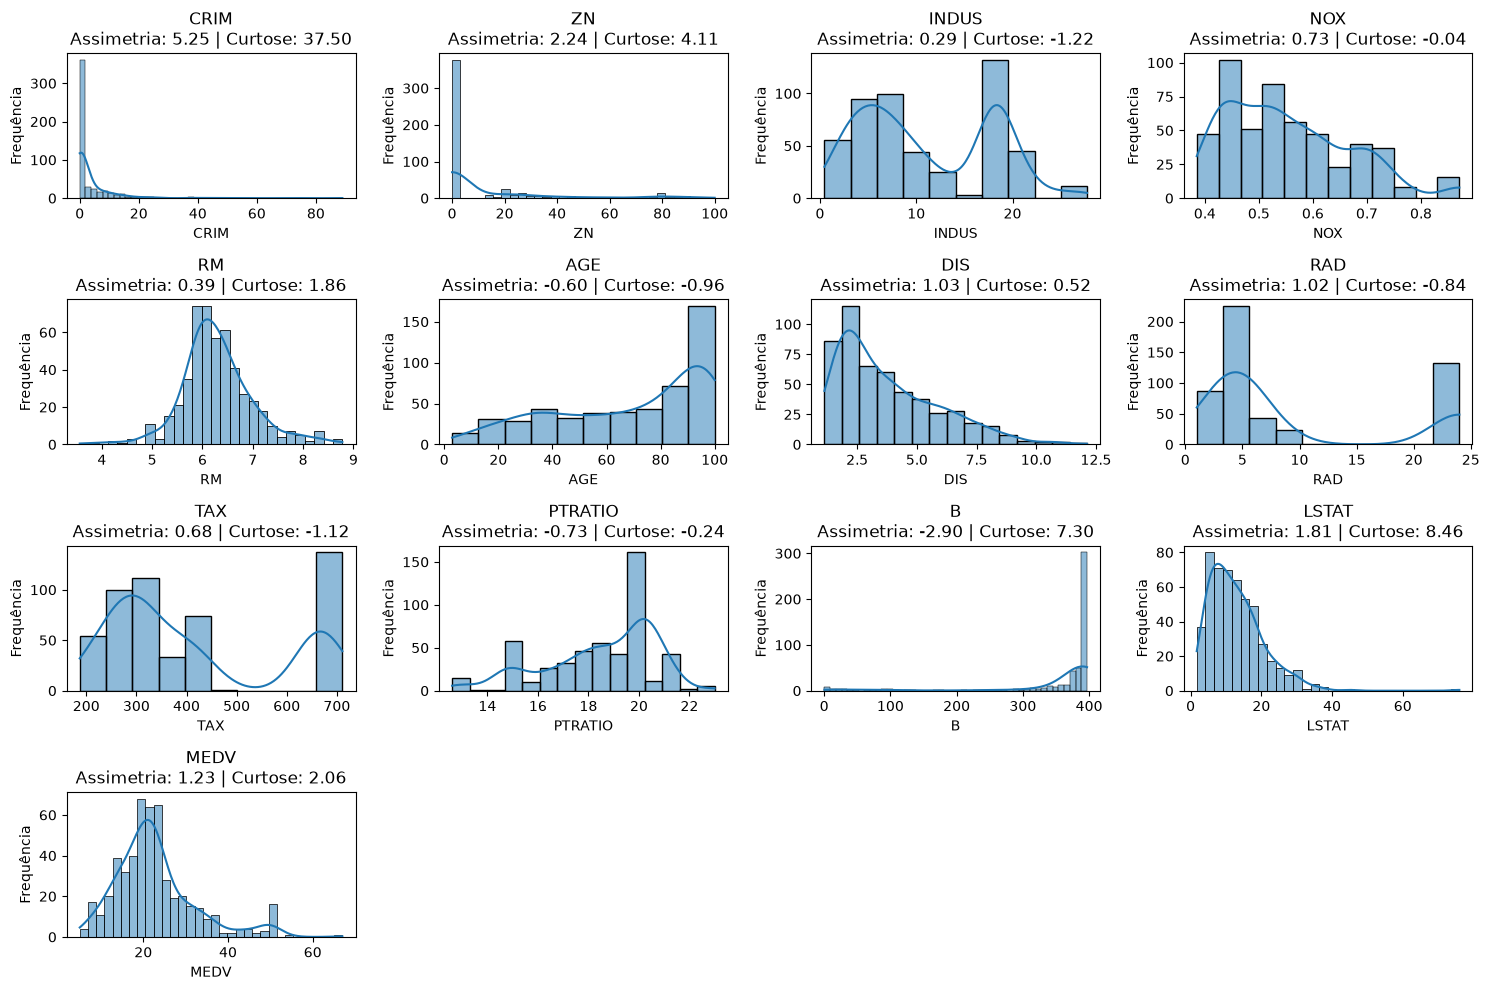

In [95]:
variaveis_hist = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV']

gerar_subplot_hist(
    variaveis=variaveis_hist,
    size=(15, 10),
    name='hist_variaveis_sem_tranformacoes'
)

In [96]:
df["logCRIM"] = np.log1p(df["CRIM"])
df["logZN"] = np.log1p(df["ZN"])
df["logDIS"] = np.log(df["DIS"])
df["logLSTAT"] = np.log(df["LSTAT"])
df["logMEDV"] = np.log(df["MEDV"])

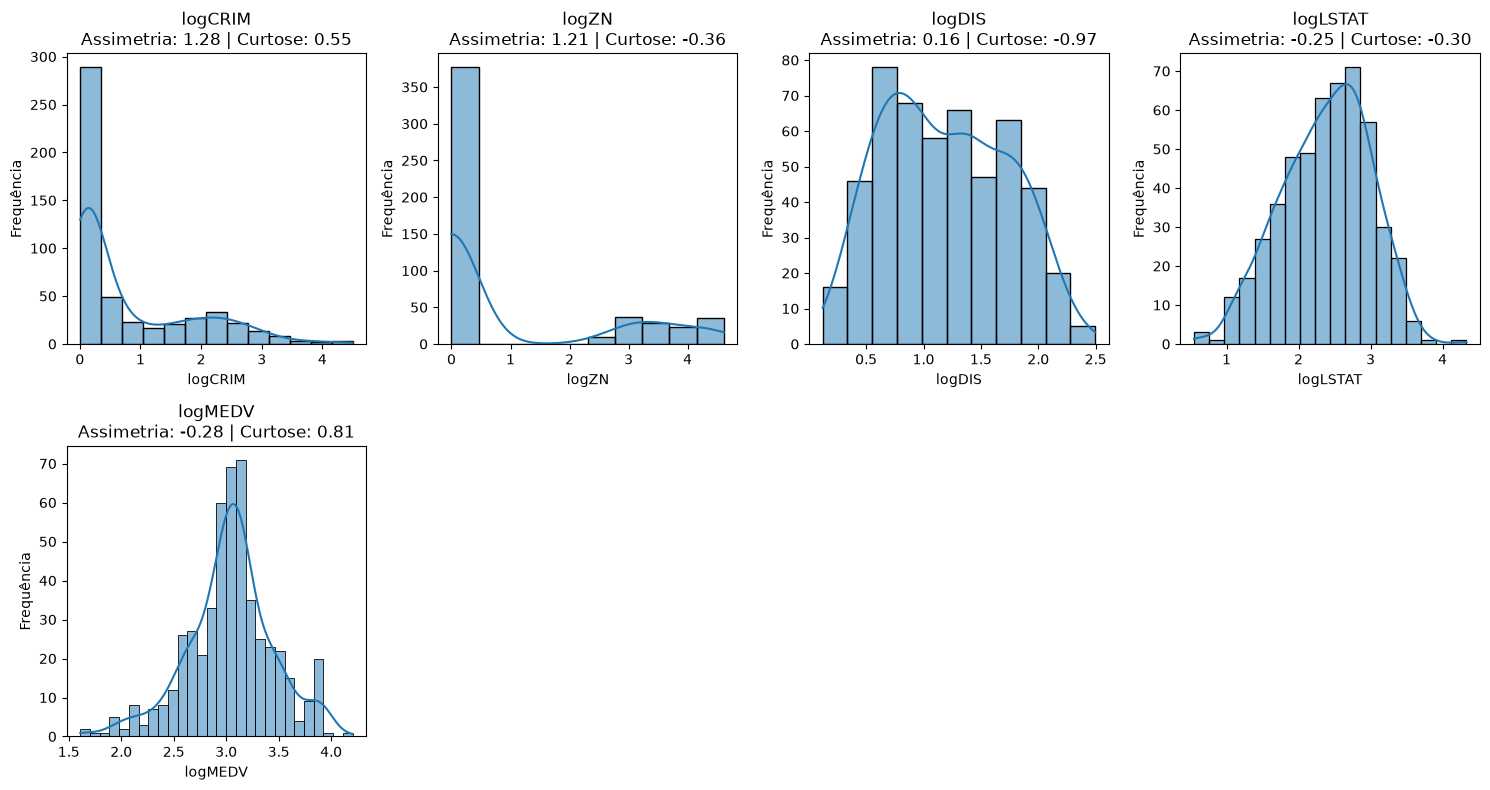

In [97]:
novas_variaveis_hist = ["logCRIM", "logZN", "logDIS", "logLSTAT", "logMEDV"]

gerar_subplot_hist(
    variaveis=novas_variaveis_hist,
    size=(15, 8),
    name='hist_variaveis_transformadas'
)

### Conclusão — Análise Univariada

A análise univariada, apoiada pela inspeção dos histogramas, das distribuições e das medidas de assimetria, revelou que algumas variáveis apresentam desvios acentuados em relação à simetria, tornando-se candidatas à aplicação de transformações antes da modelagem.

A variável `CRIM` apresentou **assimetria positiva acentuada**, com valor de 5,25. Após a aplicação da transformação logarítmica, a assimetria de `logCRIM` foi reduzida para 1,28, indicando uma melhora expressiva na simetria da distribuição. Em contrapartida, `B` apresentou assimetria negativa acentuada, de -2,90, evidenciando uma concentração das observações em uma região da distribuição e uma cauda prolongada à esquerda.

A variável resposta `MEDV` também apresentou assimetria positiva, com valor de 1,23. Após a transformação logarítmica, a assimetria de `logMEDV` passou para -0,28, indicando uma distribuição consideravelmente mais simétrica. Esse resultado reforça a possibilidade de utilizar **`log(MEDV)` como variável resposta** nos modelos posteriores, embora a escolha definitiva também deva considerar os diagnósticos dos resíduos e a censura observada no valor 50.

Outro resultado relevante foi observado em `LSTAT`, cuja assimetria passou de 1,81 para -0,25 após a transformação logarítmica. Essa redução indica que o logaritmo também é uma alternativa promissora para essa variável preditora.

Por outro lado, `ZN` manteve um comportamento bimodal mesmo após a transformação logarítmica. Isso ocorre porque a variável apresenta uma grande concentração de valores iguais a zero, característica estrutural que não é resolvida simplesmente pela transformação. Portanto, seu tratamento deverá considerar a distribuição dos valores e a possibilidade de distinguir as observações iguais a zero daquelas com valores positivos.

Em síntese, os resultados indicam que **`CRIM`, `MEDV` e `LSTAT` são candidatos relevantes à transformação logarítmica**, enquanto `B` merece uma investigação mais aprofundada devido à sua assimetria negativa. Já `ZN` exige uma abordagem que considere sua concentração de zeros e sua distribuição bimodal. Essas transformações deverão ser avaliadas também em relação às relações entre as variáveis e ao desempenho dos modelos, pois uma distribuição mais simétrica, isoladamente, não garante o atendimento aos pressupostos da regressão.


## **Parte 3: Relação de cada preditor com MEDV**

/home/luizedu/workspace/datascience/modelagem/.venv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:237: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(


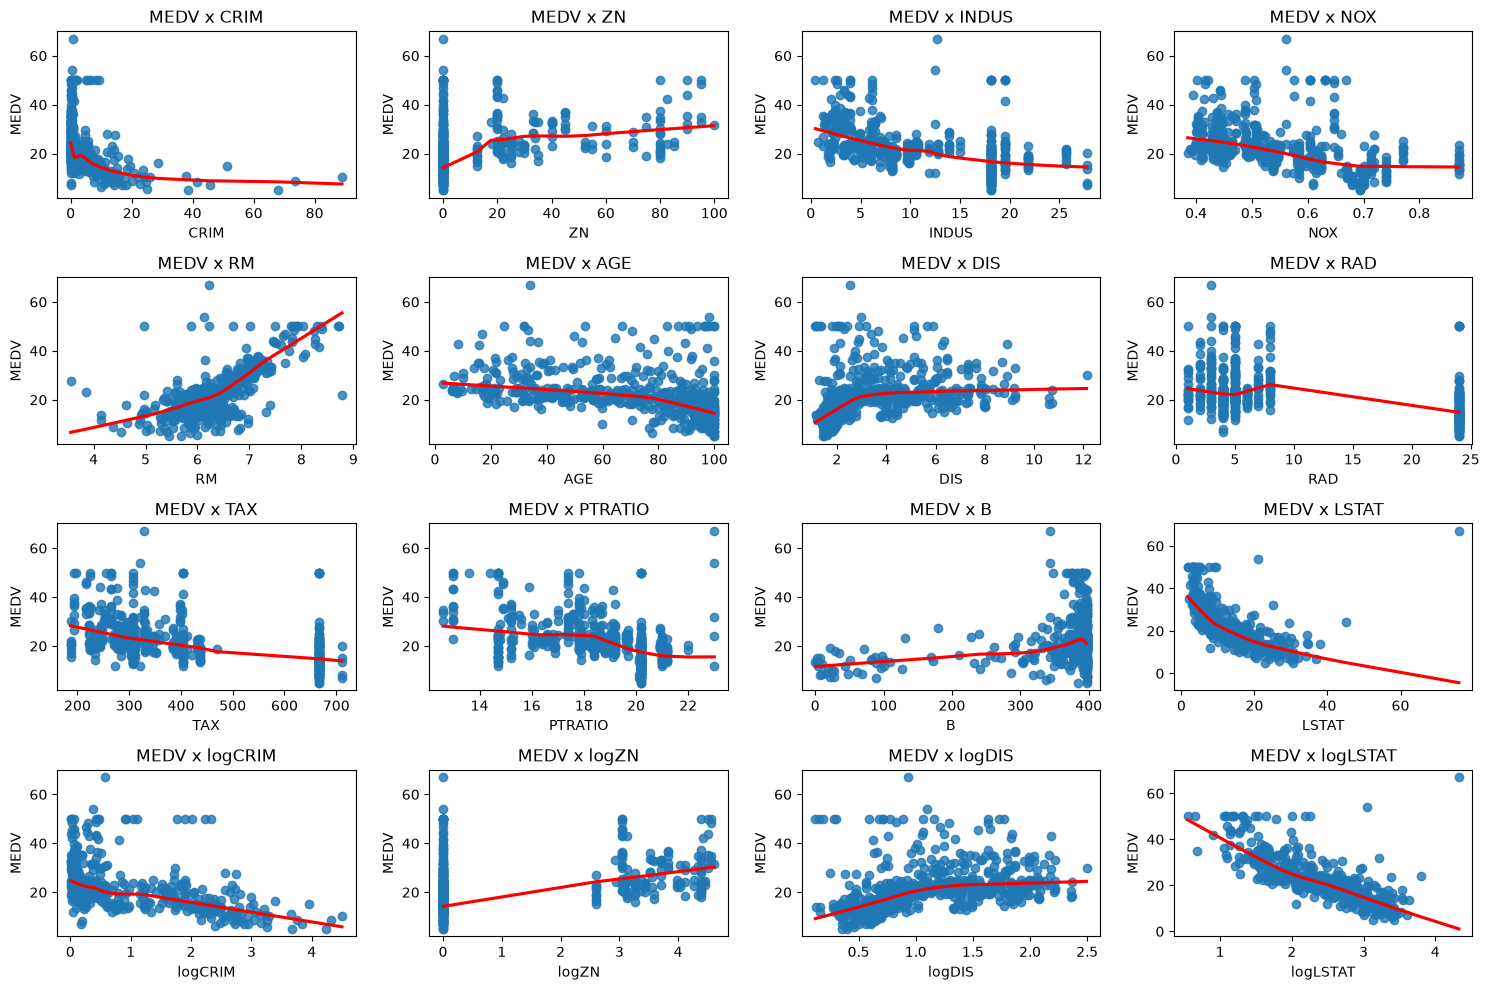

In [98]:
variaveis_regplot = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', "logCRIM", "logZN", "logDIS", "logLSTAT"]

gerar_subplot_regplot(
    variaveis=variaveis_regplot,
    y='MEDV',
    size=(15, 10),
    name='MEDV_vs_variaveis'
)

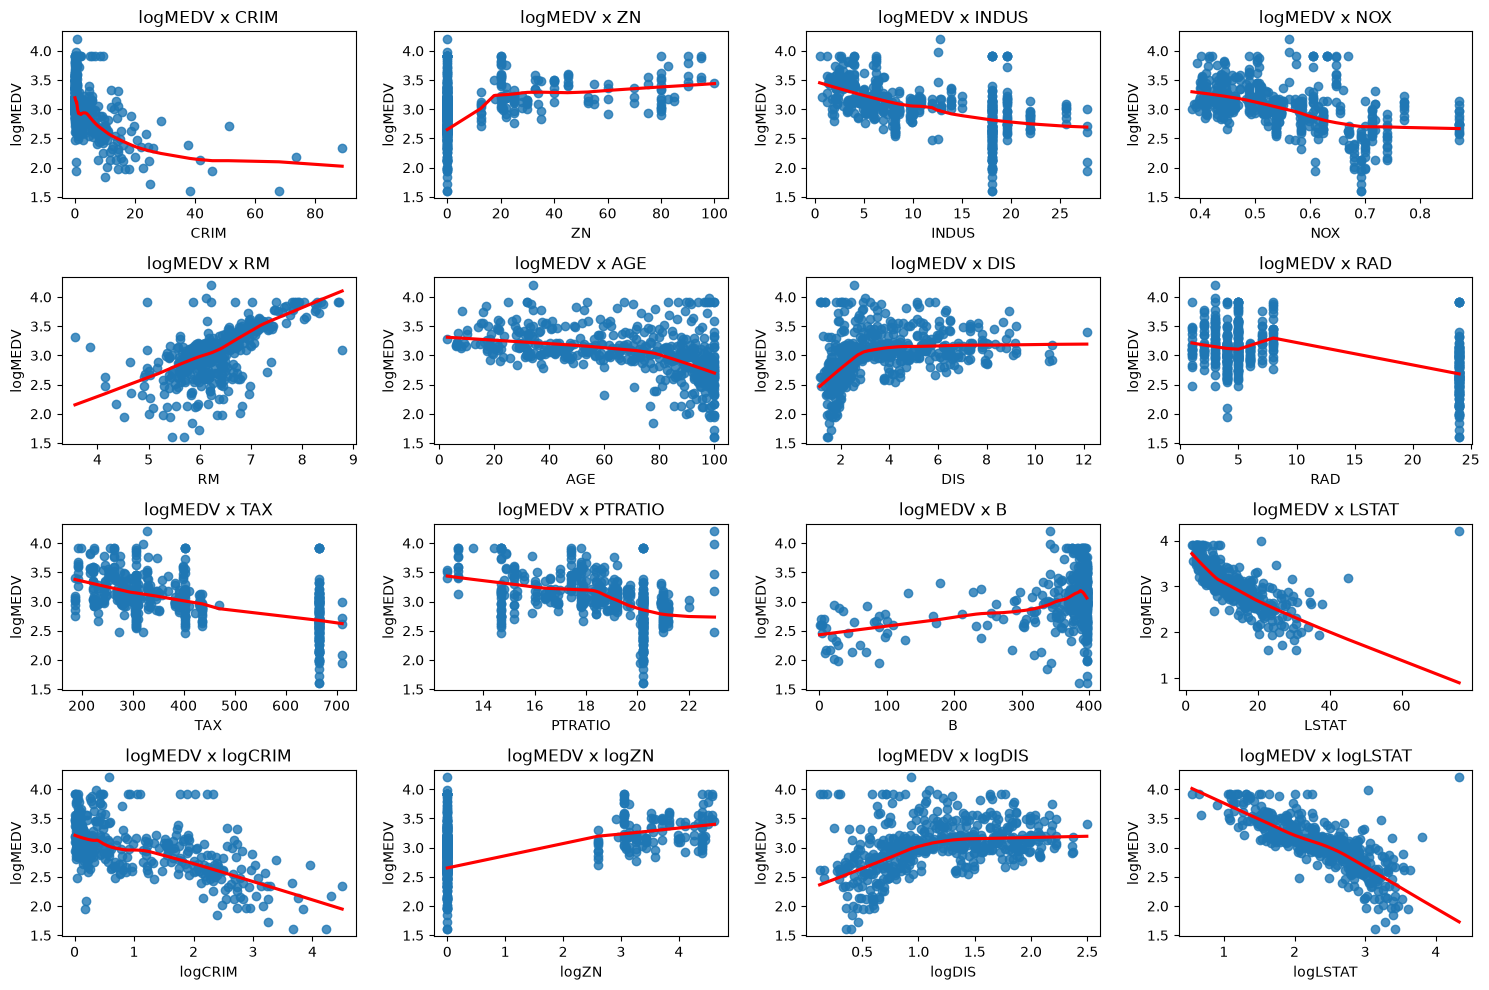

In [99]:
gerar_subplot_regplot(
    variaveis=variaveis_regplot,
    y='logMEDV',
    size=(15, 10),
    name='logMEDV_vs_variaveis'
)

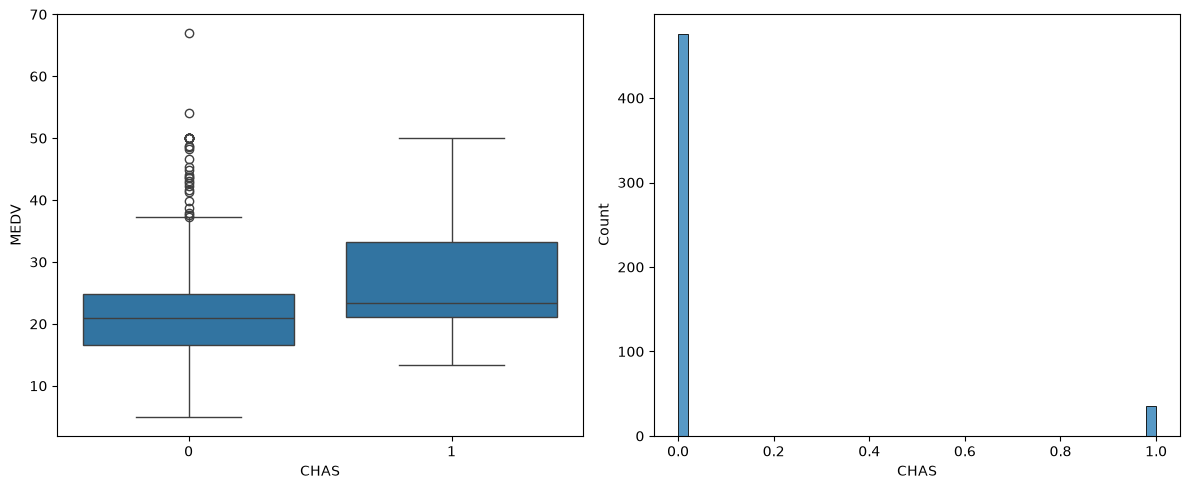

In [100]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5)
)

axes = axes.ravel()

sns.boxplot(
    data=df,
    x='CHAS',
    y='MEDV',
    ax=axes[0]
)

sns.histplot(
    data=df,
    x='CHAS',
    ax=axes[1]
)

plt.tight_layout()

plt.savefig(
    f'{output_fig_dir}/MEDV_vs_CHAS.png',
    dpi=300
)

plt.show()

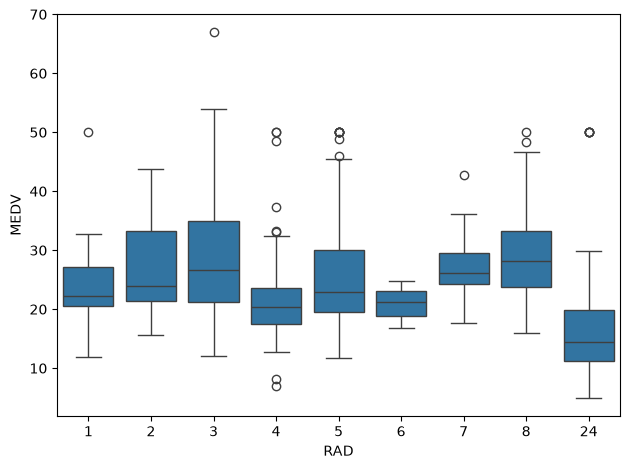

In [101]:
sns.boxplot(
    data=df,
    y='MEDV',
    x='RAD'
)

plt.tight_layout()

plt.savefig(
    f'{output_fig_dir}/MEDV_vs_RAD.png',
    dpi=300
)

plt.show()

### Conclusão — Relação dos Preditores com `MEDV`

A análise dos gráficos de dispersão, acompanhados das curvas de suavização LOWESS, revelou que as relações entre os preditores e a variável resposta `MEDV` apresentam diferentes graus de linearidade. Esse resultado é importante para a construção dos modelos de regressão, pois indica quais variáveis podem exigir transformações ou a inclusão de termos não lineares.

As variáveis `CRIM` e `LSTAT` apresentaram relações claramente não lineares com `MEDV`. Em ambos os casos, as transformações logarítmicas (`logCRIM` e `logLSTAT`) tornaram as relações observadas mais próximas de uma reta, indicando que essas transformações são alternativas promissoras para a modelagem.

A variável `DIS` apresentou uma relação com formato de joelho, caracterizada por um crescimento inicial mais acentuado seguido de uma tendência à estabilização. Embora a transformação `logDIS` tenha suavizado esse comportamento, ainda foi observada curvatura residual. Portanto, vale avaliar a inclusão de um termo quadrático como alternativa à transformação logarítmica.

Para `ZN`, a transformação `logZN` ajudou a evidenciar um padrão mais monotônico. Entretanto, a elevada concentração de valores iguais a zero, identificada na análise univariada, dificulta seu tratamento como uma variável contínua convencional. Uma alternativa a ser investigada é representá-la por meio de uma variável indicadora que diferencie observações com `ZN = 0` daquelas com `ZN > 0`, preservando a possibilidade de avaliar separadamente o efeito da presença de valores positivos.

Em contrapartida, `RM` apresentou uma relação aproximadamente linear e positiva com `MEDV` na escala original, não havendo, a princípio, uma justificativa clara para transformá-la. Essa relação poderá ser mantida na forma original e posteriormente avaliada pelos diagnósticos do modelo.

A variável `B` merece cautela devido à sua distribuição extremamente concentrada em torno de 400, acompanhada de uma cauda longa em direção a zero. Seu padrão de associação com `MEDV` deve ser interpretado considerando essa distribuição e a possibilidade de agrupamentos ou particularidades dos dados, sem presumir uma relação causal. Assim, sua contribuição para a modelagem deverá ser avaliada com atenção.

#### Análise de `CHAS` e `RAD` como fatores de agrupamento

O boxplot de `MEDV` por `CHAS` mostrou uma mediana mais elevada para `CHAS = 1`, aproximadamente 23, em comparação com cerca de 21 para `CHAS = 0`. Essa diferença sugere uma possível associação entre a proximidade do rio Charles, representada pela variável indicadora, e o valor mediano dos imóveis. Portanto, é pertinente manter `CHAS` como candidata a preditora, verificando sua contribuição nos modelos ajustados.

Já o boxplot de `MEDV` por `RAD` revelou um padrão distinto para a categoria `RAD = 24`, que apresentou a menor mediana de `MEDV` e o maior volume de observações. Esse comportamento sugere a existência de um agrupamento específico que pode não ser adequadamente representado por uma relação linear simples entre `RAD` e `MEDV`. Além disso, a estrutura dessa variável deverá ser considerada em conjunto com sua elevada associação com `TAX`, investigada na análise de multicolinearidade.

Diante disso, vale comparar a representação de `RAD` como variável numérica com sua representação como fator categórico, verificando se essa última captura melhor as diferenças entre os grupos. Também pode ser útil investigar separadamente o grupo `RAD = 24`, desde que essa decisão seja fundamentada nos dados e avaliada quanto à sua contribuição para o modelo.

Em síntese, a análise indica que **`logCRIM` e `logLSTAT` são alternativas promissoras para aproximar relações não lineares de relações lineares**, enquanto `DIS` pode exigir uma abordagem adicional para representar sua curvatura. `RM` pode ser mantida inicialmente na escala original, e `ZN`, `B`, `CHAS` e `RAD` merecem tratamentos específicos de acordo com suas características e padrões observados.

Essas conclusões orientam a seleção das formas funcionais que serão testadas na modelagem. A decisão final deverá considerar não apenas o formato dos gráficos, mas também a significância dos termos, o ajuste dos modelos e os diagnósticos dos resíduos.

## **Parte 4: Multicolinearidade**

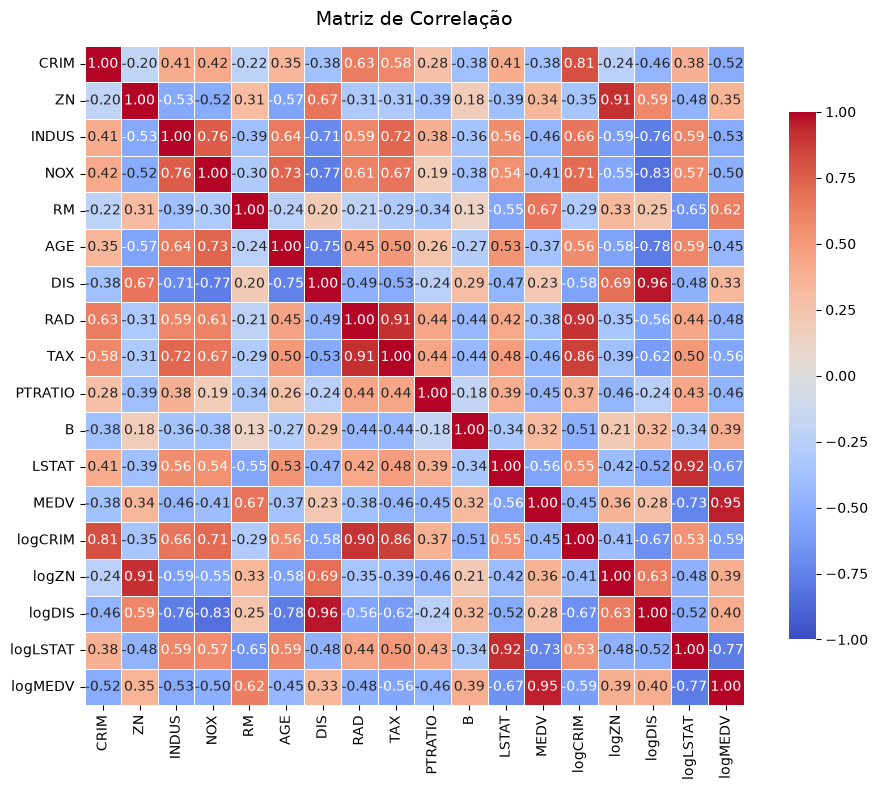

In [102]:
corr = df.drop(columns='CHAS').corr(numeric_only=True)
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',               
    cmap='coolwarm',         
    vmin=-1, vmax=1,         
    center=0,                
    square=True,             
    linewidths=0.5,             
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlação', fontsize=14, pad=15)
plt.tight_layout()

plt.savefig(
    f'{output_fig_dir}/heatmap_de_correlacao.png',
    dpi=300
)

plt.show()

In [103]:
colunas_explicativas = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
    'PTRATIO', 'B', 'LSTAT', 'MEDV']

calcular_vif(df, colunas_explicativas)

,Variável,VIF
8,TAX,9.055855
7,RAD,7.477947
3,NOX,4.477538
6,DIS,4.373359
2,INDUS,3.943290
5,AGE,2.886216
12,MEDV,2.634881
1,ZN,2.339555
11,LSTAT,2.216003
4,RM,2.165980


In [104]:
colunas_explicativas = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
    'PTRATIO', 'B', 'LSTAT', 'MEDV']

calcular_vif(df, colunas_explicativas)

,Variável,VIF
3,NOX,4.465002
6,DIS,4.372759
2,INDUS,3.229530
5,AGE,2.886167
7,RAD,2.747588
11,MEDV,2.589851
10,LSTAT,2.215486
1,ZN,2.212351
4,RM,2.165898
0,CRIM,1.824321


In [105]:
colunas_explicativas2 = ['logCRIM', 'logZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
    'PTRATIO', 'logLSTAT']

print(calcular_vif(df, colunas_explicativas2))

   Variável       VIF
0   logCRIM  7.467678
7       RAD  6.387369
3       NOX  4.429102
6       DIS  4.043972
2     INDUS  3.226616
5       AGE  3.015691
9  logLSTAT  2.950992
1     logZN  2.516669
4        RM  1.945838
8   PTRATIO  1.874155


In [106]:
colunas_explicativas2 = ['CRIM', 'logZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
    'PTRATIO', 'logLSTAT']

print(calcular_vif(df, colunas_explicativas2))

   Variável       VIF
3       NOX  4.330378
6       DIS  4.065647
2     INDUS  3.224452
5       AGE  3.003442
9  logLSTAT  2.929822
7       RAD  2.692163
1     logZN  2.524838
4        RM  1.942328
8   PTRATIO  1.858371
0      CRIM  1.711493


### Conclusão — Multicolinearidade

A análise de multicolinearidade por meio do **Variance Inflation Factor (VIF)** identificou uma associação relevante entre as variáveis `TAX` e `RAD`, sendo esse o principal ponto de atenção para a construção dos modelos de regressão.

No modelo contendo ambas as variáveis, `TAX` apresentou VIF de aproximadamente **9,06**, enquanto `RAD` apresentou VIF de **7,48**. Embora esses valores estejam abaixo do limite de referência de 10, ambos indicam multicolinearidade que merece atenção. Esse resultado é reforçado pela matriz de correlação, que apresentou uma correlação de aproximadamente **0,91** entre as duas variáveis.

Para investigar esse comportamento, foi recalculado o VIF após a remoção de `TAX`. Nessa configuração, o VIF de `RAD` caiu para aproximadamente **2,75**, enquanto os VIFs das demais variáveis permaneceram abaixo de 4,5. Essa redução indica que uma parcela importante da multicolinearidade identificada no modelo inicial está associada à presença simultânea de `TAX` e `RAD`.

A redundância entre essas variáveis pode estar relacionada à estrutura dos dados e à associação entre características regionais, tributárias e de acessibilidade rodoviária. Os agrupamentos observados nos histogramas e nos gráficos dessas variáveis reforçam a necessidade de investigar esse comportamento, embora não sejam suficientes, isoladamente, para estabelecer sua causa.

Diante desses resultados, **a remoção de `TAX` é uma alternativa a ser considerada**, mantendo `RAD` no modelo. A decisão, entretanto, não deve se basear exclusivamente nos valores de VIF: também é importante considerar a relevância teórica de cada variável e comparar o ajuste e os diagnósticos dos modelos com diferentes especificações. Uma alternativa é ajustar modelos com `TAX` e sem `TAX`, mantendo as demais condições comparáveis, e avaliar as diferenças encontradas. A remoção de `RAD`, em vez de `TAX`, também pode ser investigada caso exista justificativa para essa escolha.

Em síntese, **a multicolinearidade entre `TAX` e `RAD` é o principal problema identificado nesta etapa**, enquanto os demais preditores apresentam níveis de VIF relativamente controlados. Esses resultados fornecem subsídios para a seleção das variáveis e para a construção de um modelo de regressão mais estável e interpretável.

## Adicionando informações ao conjunto de dados

In [107]:
df.to_csv('../data/housing_processed.csv', index=False)